In [1]:
import sys

print(sys.executable)

c:\Users\BIJOHN SHIJU\Desktop\Emotion_Project\venv\Scripts\python.exe


In [2]:
!pip install pandas numpy scikit-learn transformers datasets accelerate evaluate


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import torch

print("All libraries imported successfully")

All libraries imported successfully


In [4]:
print(torch.cuda.is_available())

print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [5]:
df = pd.read_csv("cleaned_emotion_dataset.csv")

print(df.head())

                                                text  label
0                                     that game hurt      9
1  sexuality shouldnt be a grouping category it m...      7
2         you do right if you dont care then fuck em      7
3                                  man i love reddit      6
4    name was nowhere near them he was by the falcon      7


In [6]:
df = df.dropna()

df["text"] = df["text"].astype(str)

df["label"] = df["label"].astype(int)

In [7]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42
)

In [8]:
print(type(train_texts[0]))

print(train_texts[0])

<class 'str'>
mlb rangers beat the yankees on josh hamiltons walkoff single in th inning


In [9]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\BIJOHN SHIJU\Desktop\Emotion_Project\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\BIJOHN SHIJU\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [11]:
class EmotionDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [12]:
train_dataset = EmotionDataset(
    train_encodings,
    train_labels
)

test_dataset = EmotionDataset(
    test_encodings,
    test_labels
)

In [13]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=10
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5
)

In [15]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.042689,1.037691
2,0.910531,1.025366
3,0.797370,1.062624


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=19182, training_loss=0.9505989234597376, metrics={'train_runtime': 2570.0612, 'train_samples_per_second': 119.411, 'train_steps_per_second': 7.464, 'total_flos': 6114769991807400.0, 'train_loss': 0.9505989234597376, 'epoch': 3.0})

In [17]:
predictions = trainer.predict(test_dataset)

preds = predictions.predictions.argmax(-1)

print(classification_report(test_labels, preds))

NameError: name 'classification_report' is not defined

In [18]:
from sklearn.metrics import classification_report

In [19]:
predictions = trainer.predict(test_dataset)

preds = predictions.predictions.argmax(-1)

print(classification_report(test_labels, preds))

              precision    recall  f1-score   support

           0       0.54      0.57      0.55      3931
           1       0.39      0.22      0.28       199
           2       0.29      0.09      0.13        92
           3       0.38      0.39      0.38       244
           4       0.68      0.56      0.61       688
           5       0.68      0.68      0.68      5378
           6       0.55      0.59      0.57      1852
           7       0.66      0.68      0.67     10800
           8       0.41      0.30      0.35      1584
           9       0.46      0.43      0.44       807

    accuracy                           0.62     25575
   macro avg       0.50      0.45      0.47     25575
weighted avg       0.61      0.62      0.61     25575



In [20]:
label_names = {
    0: "neutral",
    1: "joy",
    2: "anger",
    3: "love",
    4: "optimism",
    5: "sadness",
    6: "gratitude",
    7: "fear",
    8: "disgust",
    9: "embarrassment"
}

In [21]:
print(
    classification_report(
        test_labels,
        preds,
        target_names=list(label_names.values())
    )
)

               precision    recall  f1-score   support

      neutral       0.54      0.57      0.55      3931
          joy       0.39      0.22      0.28       199
        anger       0.29      0.09      0.13        92
         love       0.38      0.39      0.38       244
     optimism       0.68      0.56      0.61       688
      sadness       0.68      0.68      0.68      5378
    gratitude       0.55      0.59      0.57      1852
         fear       0.66      0.68      0.67     10800
      disgust       0.41      0.30      0.35      1584
embarrassment       0.46      0.43      0.44       807

     accuracy                           0.62     25575
    macro avg       0.50      0.45      0.47     25575
 weighted avg       0.61      0.62      0.61     25575



In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names.values(),
    yticklabels=label_names.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Emotion Classification Confusion Matrix")

plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [23]:
!pip install matplotlib seaborn

     ---------------------------------------- 8.2/8.2 MB 10.1 MB/s eta 0:00:00
     -------------------------------------- 294.9/294.9 kB 9.2 MB/s eta 0:00:00
     ------------------------------------- 225.2/225.2 kB 14.3 MB/s eta 0:00:00
     ---------------------------------------- 2.3/2.3 MB 12.5 MB/s eta 0:00:00
     ---------------------------------------- 73.5/73.5 kB ? eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 7.0 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


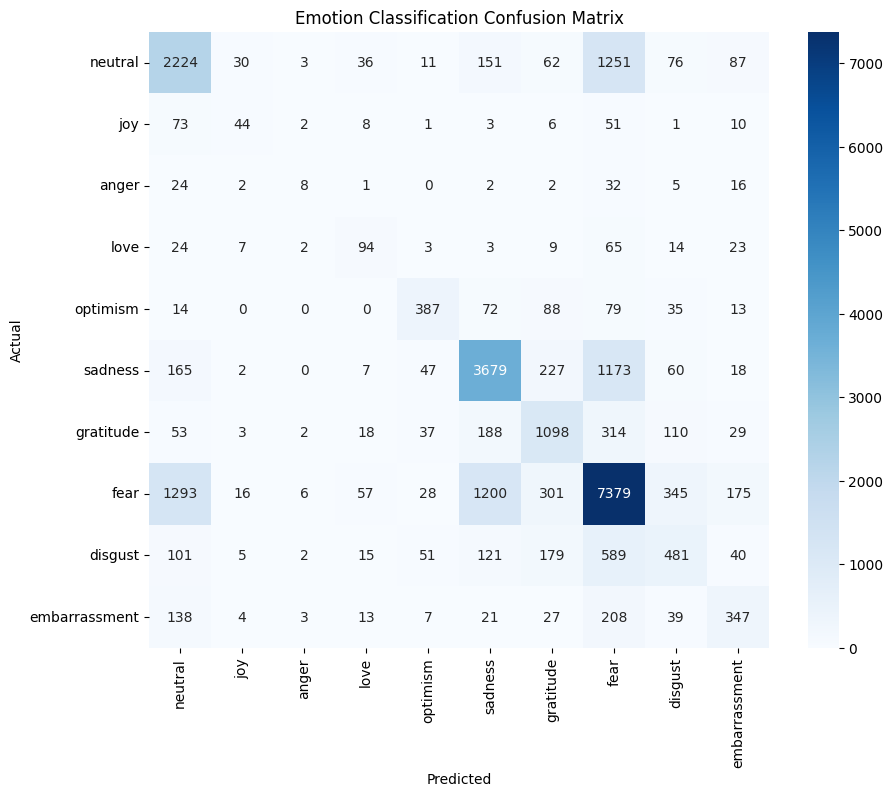

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names.values(),
    yticklabels=label_names.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Emotion Classification Confusion Matrix")

plt.show()